In [1]:
import pandas as pd
df = pd.read_csv("/Users/j/Documents/PROJECTS/Sleep and Lifestyle/Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
print(df.shape)
print(df.dtypes)


(374, 13)
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object


## Step 3 — Missing Values
Checking which columns have missing data before cleaning anything.
`isna()` returns True/False per cell, `.sum()` counts the missing per column.

In [3]:
df.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

There are around 219 missing values, but after confirming with the dataset, missing values means that there is No Sleep Disorder and hence we replace the missing values with "None"

In [4]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# Verify it worked
df["Sleep Disorder"].value_counts()

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

We drop the personID because it brings no relevant information and every single row is unique

In [5]:
df = df.drop(columns=["Person ID"])
print(df.shape)

(374, 12)


The blood pressure is stored as a string and two numbers squished together. We would split it into two columns (systolic (top number) and diastolic (bottom number)) and then drop the blood pressure column

In [6]:
df[["BP_Systolic", "BP_Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True).astype(int)

df = df.drop(columns=["Blood Pressure"])

df[["BP_Systolic", "BP_Diastolic"]].head()

,BP_Systolic,BP_Diastolic
0,126,83
1,125,80
2,125,80
3,140,90
4,140,90


Now we change the column names because they contain space in between, for example Stress Level and it becomes a nuance to then use a brack notation. So we replace the space in column name with "_" , so "Stess Level" becomes "Stess_Level"

In [7]:
df.columns = df.columns.str.replace(" ", "_")

print(df.columns.tolist())

['Gender', 'Age', 'Occupation', 'Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level', 'BMI_Category', 'Heart_Rate', 'Daily_Steps', 'Sleep_Disorder', 'BP_Systolic', 'BP_Diastolic']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep_Duration           374 non-null    float64
 4   Quality_of_Sleep         374 non-null    int64  
 5   Physical_Activity_Level  374 non-null    int64  
 6   Stress_Level             374 non-null    int64  
 7   BMI_Category             374 non-null    object 
 8   Heart_Rate               374 non-null    int64  
 9   Daily_Steps              374 non-null    int64  
 10  Sleep_Disorder           374 non-null    object 
 11  BP_Systolic              374 non-null    int64  
 12  BP_Diastolic             374 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 38.1+ KB


In [9]:
df.to_csv("../sleep_cleaned.csv", index=False)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

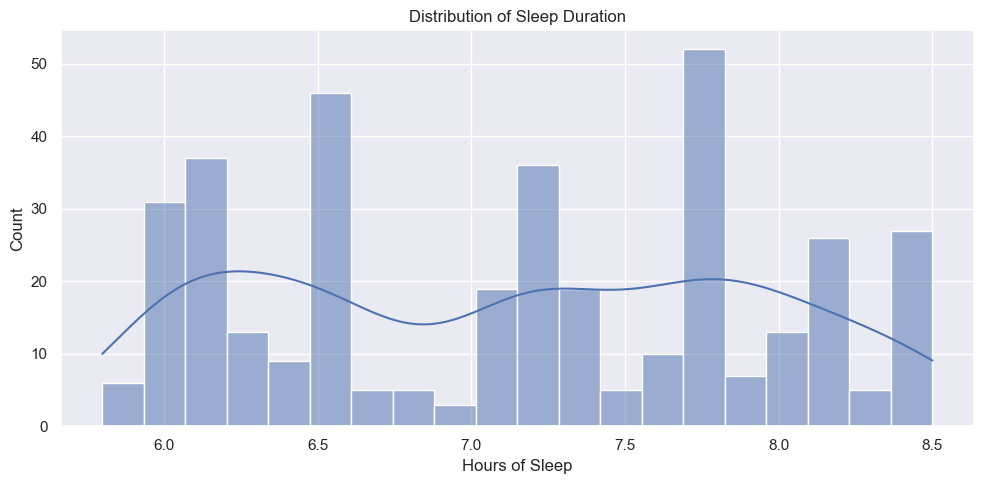

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=df, x="Sleep_Duration", bins=20, kde=True, ax=ax)

ax.set_title("Distribution of Sleep Duration")
ax.set_xlabel("Hours of Sleep")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Sleep Duration Distribution
Bimodal distribution — two distinct clusters around 6.5h and 7.8h.
Suggests two subgroups in the data worth investigating further.

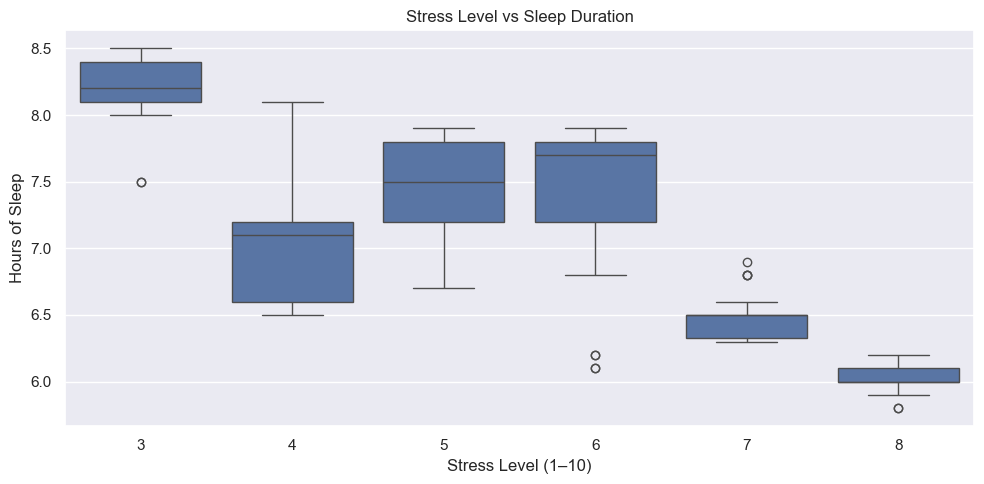

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df, x="Stress_Level", y="Sleep_Duration", ax=ax)

ax.set_title("Stress Level vs Sleep Duration")
ax.set_xlabel("Stress Level (1–10)")
ax.set_ylabel("Hours of Sleep")

plt.tight_layout()
plt.show()

## Finding 1
Clear negative relationship between stress and sleep duration.
Median sleep drops from ~8.2h (stress=3) to ~6.1h (stress=8).
High variability at stress level 4 suggests other factors at play.

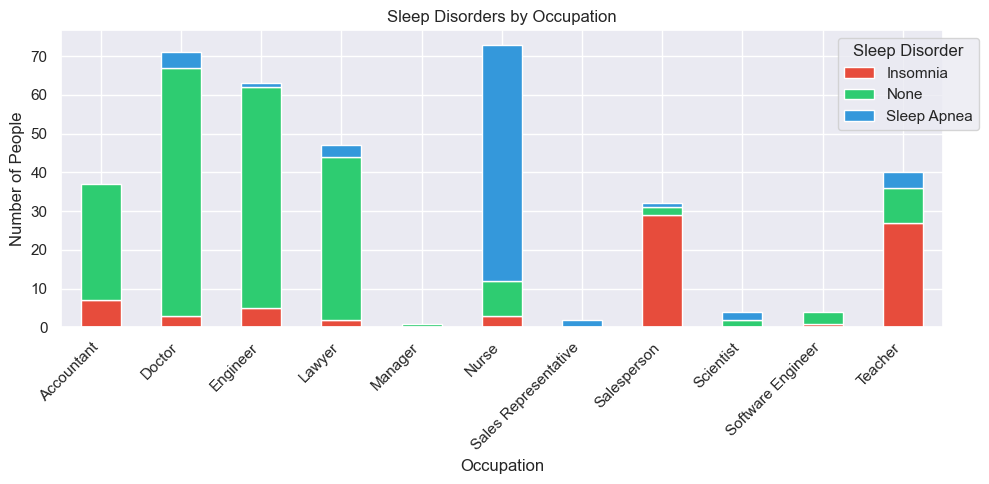

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

disorder_counts = df.groupby(["Occupation", "Sleep_Disorder"]).size().unstack()
disorder_counts.plot(kind="bar", stacked=True, ax=ax, 
                     color=["#e74c3c","#2ecc71", "#3498db"])

ax.set_title("Sleep Disorders by Occupation")
ax.set_xlabel("Occupation")
ax.set_ylabel("Number of People")
ax.legend(title="Sleep Disorder", bbox_to_anchor=(1.05, 1))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
print(df.groupby("Occupation")["Stress_Level"].mean().sort_values(ascending=False))

Occupation
Sales Representative    8.000000
Salesperson             7.000000
Scientist               7.000000
Doctor                  6.732394
Software Engineer       6.000000
Nurse                   5.547945
Lawyer                  5.063830
Manager                 5.000000
Accountant              4.594595
Teacher                 4.525000
Engineer                3.888889
Name: Stress_Level, dtype: float64


## Finding 2
Nurses show highest Sleep Apnea rates despite moderate stress (avg 5.5) — 
likely linked to shift work rather than stress alone.
Salespersons have high Insomnia and highest stress levels (avg 7.0–8.0) — consistent.
Engineers are the healthiest sleepers and least stressed occupation in this dataset.
Always verify assumptions against the actual data.

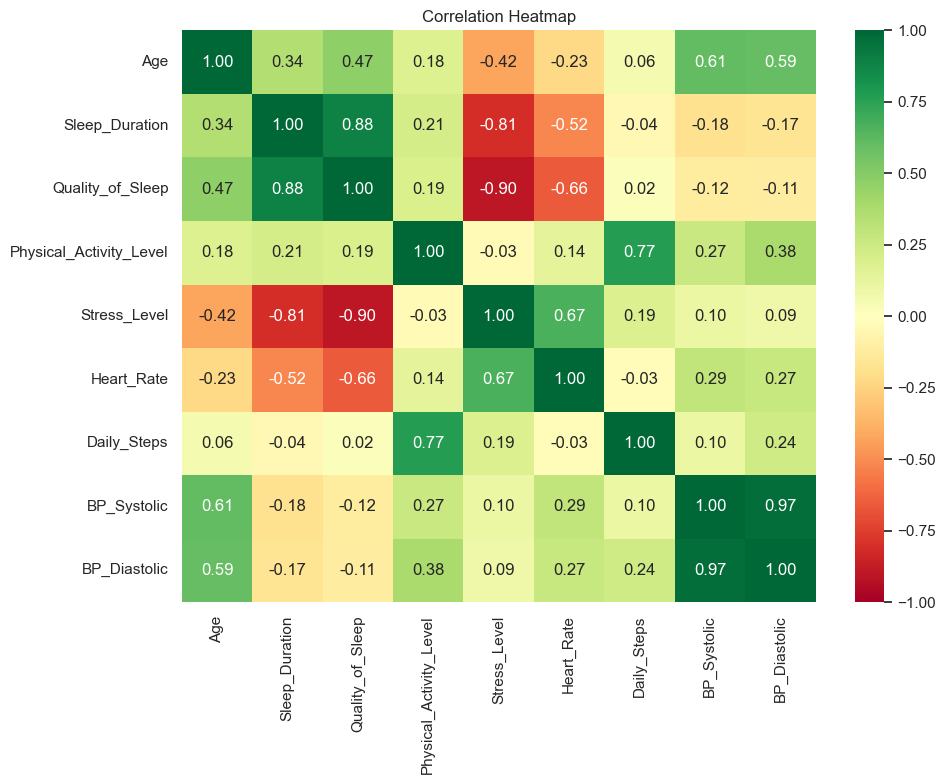

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=ax)

ax.set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## Finding 3 — Correlation Heatmap
Stress_Level is the dominant predictor of sleep quality (r = -0.90).
Heart_Rate is the second strongest predictor (r = -0.66).
Physical activity and daily steps show surprisingly weak relationships with sleep.
BP_Systolic and BP_Diastolic are nearly redundant (r = 0.97) — use only one in models.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [30]:
# Features (X) and target (y)
features = ["Stress_Level", "Heart_Rate", "Sleep_Duration", 
            "Age", "Physical_Activity_Level", "Daily_Steps"]

X = df[features]
y = df["Quality_of_Sleep"]

# Split into training and test sets — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 299 rows
Test set:     75 rows


In [31]:
# Create the model
model = LinearRegression()

# Train it
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score:  {r2:.4f}")
print(f"MAE:       {mae:.4f}")

R² Score:  0.9155
MAE:       0.2856


In [32]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values("Coefficient")

print(f"Intercept: {model.intercept_:.4f}")
print()
print(coefficients.to_string(index=False))

Intercept: 4.6138

                Feature  Coefficient
           Stress_Level    -0.322097
             Heart_Rate    -0.021016
Physical_Activity_Level    -0.000593
            Daily_Steps     0.000092
                    Age     0.013845
         Sleep_Duration     0.663843


In [33]:
import statsmodels.api as sm

# statsmodels needs the intercept added manually
X_train_sm = sm.add_constant(X_train)

model_sm = sm.OLS(y_train, X_train_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:       Quality_of_Sleep   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     468.0
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          1.42e-146
Time:                        12:39:31   Log-Likelihood:                -120.90
No. Observations:                 299   AIC:                             255.8
Df Residuals:                     292   BIC:                             281.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [34]:
features_refined = ["Stress_Level", "Heart_Rate", 
                     "Sleep_Duration", "Age", "Daily_Steps"]

X = df[features_refined]
y = df["Quality_of_Sleep"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R²:  {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

R²:  0.9155
MAE: 0.2851


Here we dropped the feature "Physical_Activity_Level" and since R2 score remained roughly the same, it suggests the feature was useless here. As we could also see with the coeff which is negligible.

In [35]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("R² per fold:", cv_scores.round(4))
print(f"Mean R²:     {cv_scores.mean():.4f}")
print(f"Std Dev:     {cv_scores.std():.4f}")

R² per fold: [0.2126 0.6823 0.8353 0.3575 0.8952]
Mean R²:     0.5966
Std Dev:     0.2676


## Model Evaluation — Linear Regression
Train/test split R² = 0.9155 — optimistic due to lucky split.
5-fold CV mean R² = 0.5966, std = 0.2677 — high variance across folds.
Indicates inconsistent patterns in the synthetic dataset.
Cross-validation is essential — single splits can be misleading.

In [36]:
from sklearn.utils import resample

n_bootstraps = 1000
r2_scores = []

for i in range(n_bootstraps):
    # Resample with replacement
    X_boot, y_boot = resample(X, y, random_state=i)
    
    # Fit model on resampled data
    model_boot = LinearRegression()
    model_boot.fit(X_boot, y_boot)
    
    # Evaluate on original test set
    y_pred_boot = model_boot.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred_boot))

r2_scores = np.array(r2_scores)

print(f"Mean R²:         {r2_scores.mean():.4f}")
print(f"Std Dev:         {r2_scores.std():.4f}")
print(f"95% CI:          [{np.percentile(r2_scores, 2.5):.4f}, {np.percentile(r2_scores, 97.5):.4f}]")

Mean R²:         0.9181
Std Dev:         0.0042
95% CI:          [0.9091, 0.9245]


## Model Stability Analysis

Three evaluation methods were used to assess the linear regression model 
predicting Quality of Sleep:

| Method                     | R²     | Notes                        |
|---------------------------|--------|------------------------------|
| Train/test split (80/20)  | 0.9155 | Single split — optimistic    |
| 5-fold cross-validation   | 0.5966 | ± 0.2677 std — high variance |
| Bootstrap (1000 iters)    | 0.9181 | 95% CI [0.909, 0.924]        |

### Interpretation
The three methods tell different stories:

- **Train/test split and Bootstrap** both show high R² (~0.92) — 
  indicating the model is internally consistent within this dataset
- **Cross-validation** reveals the real picture — R² drops to 0.60 
  with high variance across folds, meaning the model struggles to 
  generalise to unseen data subgroups

### Why the disagreement?
Bootstrap resamples from the same data distribution, so it measures 
internal consistency. Cross-validation holds out entire subgroups, 
exposing generalisation failure — a classic symptom of synthetic data 
where patterns are not consistent across the full dataset.

### Conclusion
Real-world performance on genuinely new data would likely sit closer 
to the cross-validation estimate of R² ≈ 0.60. The high bootstrap 
consistency confirms the model is stable, but not that it generalises well.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Same features as linear regression
features_log = ["Stress_Level", "Heart_Rate", 
                "Sleep_Duration", "Age", "Daily_Steps"]

X_log = df[features_log]
y_log = df["Sleep_Disorder"]

# Encode target — sklearn needs numbers, not strings
le = LabelEncoder()
y_log_encoded = le.fit_transform(y_log)

print("Classes:", le.classes_)
print("Encoded as:", list(range(len(le.classes_))))

# Train/test split
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log_encoded, test_size=0.2, random_state=42
)

Classes: ['Insomnia' 'None' 'Sleep Apnea']
Encoded as: [0, 1, 2]


In [38]:
# Create and train the model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_log, y_train_log)

# Predict
y_pred_log = log_model.predict(X_test_log)

# Evaluate
print(classification_report(y_test_log, y_pred_log, 
                             target_names=le.classes_))

              precision    recall  f1-score   support

    Insomnia       0.71      0.62      0.67        16
        None       0.89      0.98      0.93        43
 Sleep Apnea       0.71      0.62      0.67        16

    accuracy                           0.83        75
   macro avg       0.77      0.74      0.76        75
weighted avg       0.82      0.83      0.82        75



/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


On training data we use fit_transform — learn the mean and std from training data, then scale it.
On test data we use only transform — apply the same mean and std we learned from training data. We never fit on test data.
Why? Because in real life, test data represents new unseen data. You wouldn't know its mean and std in advance. If you scaled test data using its own statistics, you'd be cheating — giving the model information it wouldn't have in production. This is called data leakage and it's one of the most common mistakes in ML.

In [39]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

# Refit with scaled data
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_scaled, y_train_log)

y_pred_log = log_model.predict(X_test_scaled)

print(classification_report(y_test_log, y_pred_log,
                             target_names=le.classes_))

              precision    recall  f1-score   support

    Insomnia       0.81      0.81      0.81        16
        None       0.91      0.98      0.94        43
 Sleep Apnea       0.92      0.75      0.83        16

    accuracy                           0.89        75
   macro avg       0.88      0.85      0.86        75
weighted avg       0.89      0.89      0.89        75



## Why We Scaled the Data — StandardScaler

### The Problem
Our features lived on completely different scales:
- `Daily_Steps` → 3,000 to 10,000
- `Stress_Level` → 1 to 10
- `Heart_Rate` → 60 to 90
- `Age` → 18 to 60

### How Logistic Regression Finds Coefficients
Logistic regression uses an iterative algorithm called **gradient descent** — 
it starts with random coefficients and takes small steps downhill to minimise 
prediction error, like finding the bottom of a valley.

### What Happens Without Scaling
When features have vastly different scales, the loss surface becomes distorted — 
steep in some directions, almost flat in others. The algorithm overshoots in 
some dimensions and barely moves in others, struggling to converge. This is 
exactly why we got the ConvergenceWarning.

### What StandardScaler Does
It transforms every feature to have mean = 0 and standard deviation = 1.

Formula: x_scaled = (x - mean) / std

Example — Daily_Steps = [3000, 7000, 10000, 5000], mean = 6250, std = 2900:
scaled = [-1.12, 0.26, 1.29, -0.43]

After scaling all features live on the same scale — gradient descent 
finds the optimal coefficients efficiently.

### The Critical Rule — Never Fit the Scaler on Test Data
We learn mean and std from training data only, then apply those same 
parameters to test data. Fitting the scaler on test data would be 
**data leakage** — the model would indirectly see test statistics 
during training, making evaluation results dishonestly optimistic.

### The Result
| Metric         | Before Scaling | After Scaling |
|----------------|---------------|---------------|
| Accuracy       | 0.83          | 0.89          |
| Insomnia F1    | 0.67          | 0.81          |
| Sleep Apnea F1 | 0.67          | 0.83          |

Scaling improved every metric and eliminated the convergence warning.

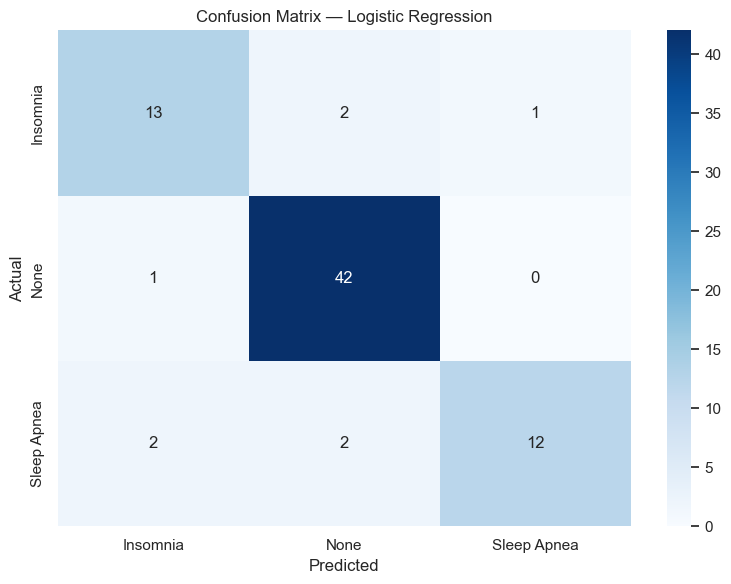

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test_log, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=ax)

ax.set_title("Confusion Matrix — Logistic Regression")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

In [41]:
log_model_balanced = LogisticRegression(max_iter=5000, random_state=42,
                                         class_weight="balanced")
log_model_balanced.fit(X_train_scaled, y_train_log)

y_pred_balanced = log_model_balanced.predict(X_test_scaled)

print(classification_report(y_test_log, y_pred_balanced,
                             target_names=le.classes_))

              precision    recall  f1-score   support

    Insomnia       0.50      0.88      0.64        16
        None       0.94      0.74      0.83        43
 Sleep Apnea       0.92      0.75      0.83        16

    accuracy                           0.77        75
   macro avg       0.79      0.79      0.77        75
weighted avg       0.84      0.77      0.79        75



## Class Imbalance — Handling and Tradeoffs

Dataset has 219 None cases vs 77-78 disorder cases — 3x imbalance.
Applied class_weight="balanced" to penalise minority class mistakes more heavily.

Tradeoff observed:
- Insomnia recall improved: 0.81 → 0.88 (catches more real cases)
- Insomnia precision dropped: 0.81 → 0.50 (more false alarms)
- Overall accuracy dropped: 0.89 → 0.77

For a health screening context, higher recall is preferred —
missing a real disorder is more costly than a false alarm.
Balanced model selected for dashboard deployment.

## Handling Class Imbalance — SMOTE

### The Problem
Our training data has a significant class imbalance:
- None → 176 rows (majority)
- Sleep Apnea → 62 rows (minority)
- Insomnia → 61 rows (minority)

None has nearly 3x more examples than the disorder classes.
This means the model has seen far more "healthy" cases during training,
making it biased towards predicting None.

### Why Simple Approaches Fall Short

**Undersampling** — remove None cases until classes are equal.
Problem: we'd drop from 299 to ~183 training rows. With only 374 rows
total, losing that much data hurts the model significantly.

**Naive Oversampling** — just duplicate Insomnia and Sleep Apnea rows.
Problem: the model memorises those exact duplicated rows rather than
learning general patterns. This leads to overfitting.

### What SMOTE Does
SMOTE — Synthetic Minority Oversampling Technique — creates brand new
synthetic examples by interpolating between existing minority class rows.

For each minority class example it:
1. Finds its nearest neighbours in feature space
2. Creates a new synthetic point somewhere between them
3. Repeats until all classes are balanced

The result is plausible new patients that could realistically exist —
not copies, but interpolations between real cases.

### The Critical Rule
SMOTE is applied only to training data — never test data.
The test set must remain the original real data to give an honest
evaluation of how the model performs on unseen cases.

### Expected Result
After SMOTE all three classes will have 176 training examples each,
giving the model equal exposure to all disorder types.

In [44]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train_log)

print("Before SMOTE:")
print(pd.Series(y_train_log).value_counts().to_dict())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE:
{1: 176, 2: 62, 0: 61}

After SMOTE:
{0: 176, 1: 176, 2: 176}


In [45]:
log_model_smote = LogisticRegression(max_iter=5000, random_state=42)
log_model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_model_smote.predict(X_test_scaled)

print(classification_report(y_test_log, y_pred_smote,
                             target_names=le.classes_))

              precision    recall  f1-score   support

    Insomnia       0.50      0.88      0.64        16
        None       0.94      0.74      0.83        43
 Sleep Apnea       0.92      0.75      0.83        16

    accuracy                           0.77        75
   macro avg       0.79      0.79      0.77        75
weighted avg       0.84      0.77      0.79        75



## Three-Way Model Comparison

| Approach          | Accuracy | Insomnia F1 | Sleep Apnea F1 | None F1 |
|-------------------|----------|-------------|----------------|---------|
| Original          | 0.89     | 0.81        | 0.83           | 0.94    |
| Balanced weights  | 0.77     | 0.64        | 0.83           | 0.83    |
| SMOTE             | 0.77     | 0.64        | 0.83           | 0.83    |

Balanced weights and SMOTE produce identical results on this dataset —
likely because the synthetic data has clean linear boundaries where
both approaches converge to the same solution.

Selected model: class_weight="balanced" — simpler, no extra dependencies,
appropriate for a health screening context where recall matters more than
overall accuracy.

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Pipeline combines scaling + model into one step
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42,
                                  class_weight="balanced"))
])

# StratifiedKFold keeps class proportions in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(pipeline, X_log, y_log_encoded, 
                             cv=cv, scoring="f1_macro")

print("F1 per fold:", cv_scores.round(4))
print(f"Mean F1:     {cv_scores.mean():.4f}")
print(f"Std Dev:     {cv_scores.std():.4f}")

F1 per fold: [0.8222 0.8504 0.7739 0.7728 0.853 ]
Mean F1:     0.8145
Std Dev:     0.0353


## Cross-Validation — Logistic Regression (Balanced, Pipeline)

F1 per fold: [0.8222, 0.8504, 0.7739, 0.7728, 0.8530]
Mean F1: 0.8145
Std Dev: 0.0353

The model is stable and consistent across all 5 folds — low variance
confirms results are not dependent on a lucky data split.

Using StratifiedKFold ensures each fold mirrors the original class
distribution. Pipeline prevents data leakage by fitting the scaler
independently on each fold's training data.

Logistic regression significantly outperforms linear regression on
this dataset — categorical disorder labels have cleaner boundaries
than continuous sleep quality scores.

In [47]:
import streamlit as st

st.title("My App")           # renders a title
st.write("Hello world")      # renders text
x = st.slider("Pick a number", 1, 10)  # renders an interactive slider
st.write(f"You picked {x}")  # updates live when slider moves

2026-04-23 13:37:12.791 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 13:37:12.872 
  command:

    streamlit run /opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-23 13:37:12.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 13:37:12.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 13:37:12.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 13:37:12.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 13:37:12.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 13:37:12.874 Thread 'MainThread': m